In [6]:
import warnings
warnings.filterwarnings("ignore")

import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pandas as pd
import glob
import yaml
import astropy.wcs.wcs as wcs
from astropy.nddata import Cutout2D
import aplpy

import sys
# sys.path.append(os.path.abspath(".."))
# from scripts._create_figs import create_m0_map, create_m8_map, create_fig, mark_sources, create_cont_map, plot_vector, getIdx, plot_outflow_and_separation_vectors

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)
IMAGE_DIRECTORY = config["data_dir"]

In [7]:
# SET OUTPUT
output_folder = "test"
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

# READ DATA
outflow_data = pd.read_csv('../data/output/outflow_data.csv')
outflow_data2 = outflow_data.groupby('field').first().reset_index()
by_field = pd.read_csv('../data/output/data_by_field.csv')
source_info = pd.read_csv("../data/output/source_info.csv", index_col='Main')
source_info.index = source_info.index.str.casefold()

cont_files = glob.glob(f'{IMAGE_DIRECTORY}/*/*cont*.fits')
spw39_files = glob.glob(f'{IMAGE_DIRECTORY}/*/*12co*.fits') + glob.glob(f'{IMAGE_DIRECTORY}/*/*spw39*.fits')
if len(cont_files) != len(spw39_files):
    raise ValueError("Number of continuum files does not match number of 12CO/SPW39 files.")

# SCRIPT
# define fields in each figure
fig_1 = ['HOPS-32', 'HOPS-168', 'HOPS-281', 'Per-emb-17']
fig_2 = ['HOPS-290', 'HOPS-288']
no_outflows = ['HOPS-28', 'HOPS-163', 'HOPS-242', 'HOPS-255', 'HOPS-248', 'HOPS-357']
app_1 = by_field[~by_field['field'].isin(no_outflows)]['field'].values
app_2 = by_field[by_field['field'].isin(no_outflows)]['field'].values

In [8]:
### READ DATA
# verify output path exists and
# skip already existing files if you don't want to overwrite them
target_name = "HOPS-168"

# open images
spw39_file = spw39_files[next((i for i, s in enumerate(spw39_files) if target_name.casefold() in s), None)]
cont_file = cont_files[next((i for i, s in enumerate(cont_files) if target_name.casefold() in s), None)]
hdu_cont = fits.open(cont_file)[0]
hdu_spw39 = fits.open(spw39_file)[0]
distance = source_info.loc[target_name.casefold(), 'Dis'].iloc[0]
target_info = source_info.loc[target_name.casefold()]

In [9]:
def create_fig(img, distance=0, scalebar_au=500, figure=plt.figure(figsize=(6,6)), subplot=(1,1,1), multiimage=False, small_plot=False):
    # Create FITSFigure
    if not multiimage:
        figure.clear()

    fig = aplpy.FITSFigure(img, figure=figure, subplot=subplot)

    # Display image
    fig.show_colorscale(cmap='viridis', stretch='sqrt')

    # Title
    fig.set_title(img.header['OBJECT'])

    # Colorbar
    fig.add_colorbar()
    fig.colorbar.set_axis_label_text("Intensity (Jy/Beam)")
    fig.colorbar.set_location('right')
    fig.colorbar.set_pad(0.0)

    # Scalebar
    if distance == 0:
        fig.add_scalebar(1 * u.arcsecond)
        fig.scalebar.set_label('1"')
    else:
        fig.add_scalebar((scalebar_au / (distance)) * u.arcsecond)
        fig.scalebar.set_label(f"{scalebar_au} au")
        fig.scalebar.set_font_size(8)

    fig.scalebar.set_linewidth(3)

    # Beam
    fig.add_beam()
    fig.beam.show()
    fig.beam.set_corner("bottom left")
    fig.beam.set_color("black")
    fig.beam.set_edgecolor("black")
    fig.beam.set_facecolor("white")

    # OFFSET TICK LABELS
    # hide aplpy ticks
    fig.tick_labels.hide()
    # enable plain Matplotlib ticks
    fig.ax.tick_params(axis='both', which='both', direction='out', length=5, labelsize=10)
    fig.ax.xaxis.set_visible(True)
    fig.ax.yaxis.set_visible(True)

    # create offset ticks
    tick_spacing = 5  # arcsec
    xticks_new = np.arange(-20, 21, tick_spacing)
    yticks_new = np.arange(-20, 21, tick_spacing)
    # convert offsets to pixel positions
    pixscale = np.mean(np.abs(fig._wcs.pixel_scale_matrix.diagonal())) * 3600
    x_center = fig._data.shape[1]/2
    y_center = fig._data.shape[0]/2
    xticks_pix_new = xticks_new / pixscale + x_center
    yticks_pix_new = yticks_new / pixscale + y_center

    # Apply new tick positions and labels
    fig.ax.set_xticks(xticks_pix_new)
    fig.ax.set_yticks(yticks_pix_new)
    fig.ax.set_xticklabels([f"{x:.0f}" for x in xticks_new])
    fig.ax.set_yticklabels([f"{y:.0f}" for y in yticks_new])
    fig.axis_labels.set_xtext("RA Offset (arcsec)")
    fig.axis_labels.set_ytext("Dec Offset (arcsec)")
    fig.axis_labels.set_xpad(3)
    fig.axis_labels.set_ypad(3)

    # figure.show()
    return fig

def cut_fig(data, header, center=None, size=None):
    # get the wcs
    wcs_original = wcs.WCS(header)
    wcs_2d = wcs_original.celestial

    # center and size
    if center == None:
        center = SkyCoord(header['OBSRA'], header['OBSDEC'], unit=u.degree)
    if size == None:
        size = np.array([39, 39]) * u.arcsecond

    # make the cut
    cut = Cutout2D(data, center, size, wcs=wcs_2d)

    # create a header with the wcs
    # CAUTION: lots of header data not being preserved here
    new_header = cut.wcs.to_header()
    for key in ['BUNIT', 'OBJECT', 'TELESCOP', 'INSTRUME', 'BMAJ', 'BMIN', 'BPA', 'OBSRA', 'OBSDEC']:
        if key in header:
            new_header[key] = header[key]

    # combine cut and wcs and an HDU
    return fits.PrimaryHDU(data=cut.data, header=new_header)

def create_m8_map(hdu, center=None, size=None, distance=0, figure=plt.figure(figsize=(6,6)), subplot=(1,1,1), multiimage=False):
    # create map
    m8_map = np.max(hdu.data[0,:,:,:], axis=0)

    cut = cut_fig(m8_map, hdu.header, center, size)
    
    return create_fig(cut, distance=distance, figure=figure, subplot=subplot, multiimage=multiimage)

def create_cont_map_2(hdu, center=None, size=None, distance=0, scalebar_au=500, figure=plt.figure(figsize=(6,6)), subplot=(1,1,1), multiimage=False, small_plot=False):

    cut = cut_fig(hdu.data[0,0,:,:], hdu.header, center, size)
    
    fig = create_fig(cut, distance=distance, scalebar_au=scalebar_au, figure=figure, subplot=subplot, multiimage=multiimage, small_plot=small_plot)
    fig.axis_labels.hide()
    fig.colorbar.hide()
    fig.ticks.hide()
    fig.tick_labels.hide()
    return fig


<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

INFO: Auto-setting vmin to  5.192e-03 [aplpy.core]
INFO: Auto-setting vmax to  5.058e-02 [aplpy.core]


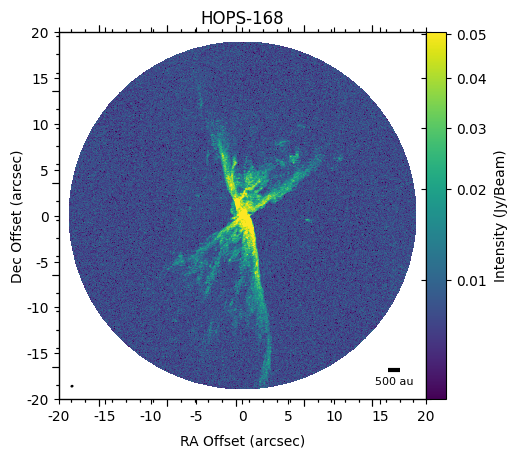

In [10]:
figure = plt.figure(figsize=(5,8))
fig = create_m8_map(hdu_spw39, distance=distance, figure=figure)


In [11]:
center

NameError: name 'center' is not defined

In [ ]:
fig.ax.get_xticks()

array([ -19.23076923,  173.07692308,  365.38461538,  557.69230769,
        750.        ,  942.30769231, 1134.61538462, 1326.92307692,
       1519.23076923])

In [ ]:
fig.ax.get_yticks()

array([ -19.23076923,  173.07692308,  365.38461538,  557.69230769,
        750.        ,  942.30769231, 1134.61538462, 1326.92307692,
       1519.23076923])

In [ ]:
fig.ax.get_xticklabels()

[Text(-19.23076923079293, 0, '-20'),
 Text(173.07692307690536, 0, '-15'),
 Text(365.38461538460353, 0, '-10'),
 Text(557.6923076923017, 0, '-5'),
 Text(750.0, 0, '0'),
 Text(942.3076923076983, 0, '5'),
 Text(1134.6153846153966, 0, '10'),
 Text(1326.9230769230946, 0, '15'),
 Text(1519.230769230793, 0, '20')]